# Correlation Matrix Generator

---

## Purpose

This tool performs Pearson correlation analysis to:
1. Calculate correlation coefficients between all pairs of material properties
2. Generate publication-quality heatmap visualizations with LaTeX labels and data tables (CSV)

**Pearson Correlation Coefficient:**

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

where $r_{xy} \in [-1, 1]$:
- $r = +1$: Perfect positive correlation
- $r = 0$: No linear correlation  
- $r = -1$: Perfect negative correlation

---

## Requirements

- **Python 3.12+**
- **Libraries:** pandas, seaborn, matplotlib, openpyxl
- See `requirements.txt` for exact versions

**Install dependencies:**
```bash
pip install -r requirements.txt
```

---

## Usage

1. **Run the notebook:** `jupyter notebook correlation_matrix_generator.ipynb`
2. **Follow the interactive prompts to:**
   - Specify your data file location (Excel/CSV)
   - Drop identifier columns (`auid`, `MP_ID`, `formula`)
   - Configure LaTeX labels (optional)
   - Set visualization parameters
   - Choose where to save results

---

## Output

- **PDF:** High-resolution correlation heatmap with LaTeX symbols
- **CSV:** Correlation matrix with original column names

---

CORRELATION MATRIX GENERATOR

STEP 1: LOAD DATA FILE



Load file from home directory? (yes/no):  no



Enter the directory path containing your data file:
Press Enter to use default: C:\Users\SVI


Enter path:  C:\



Available files:
1. AFLOW_cleaned_dataset.csv
2. MP_cleaned_dataset.csv


...


STEP 4: CALCULATING CORRELATION
Correlation matrix calculated successfully!
Figure size: 42.0 x 42.0

STEP 6: GENERATING VISUALIZATION
Visualization created!

STEP 7: SAVE RESULTS



Save results to home directory? (yes/no):  no



Enter directory path for saving results:
Press Enter to use default: C:\Users\SVI


Enter path:  C:\

Enter prefix for output files:  MP_CM


Figure saved: C:\Corr_matrix\MP_CM_matrix.pdf and C:\Corr_matrix\MP_CM_matrix.png
CSV saved (with original column names): C:\Corr_matrix\MP_CM_matrix.csv


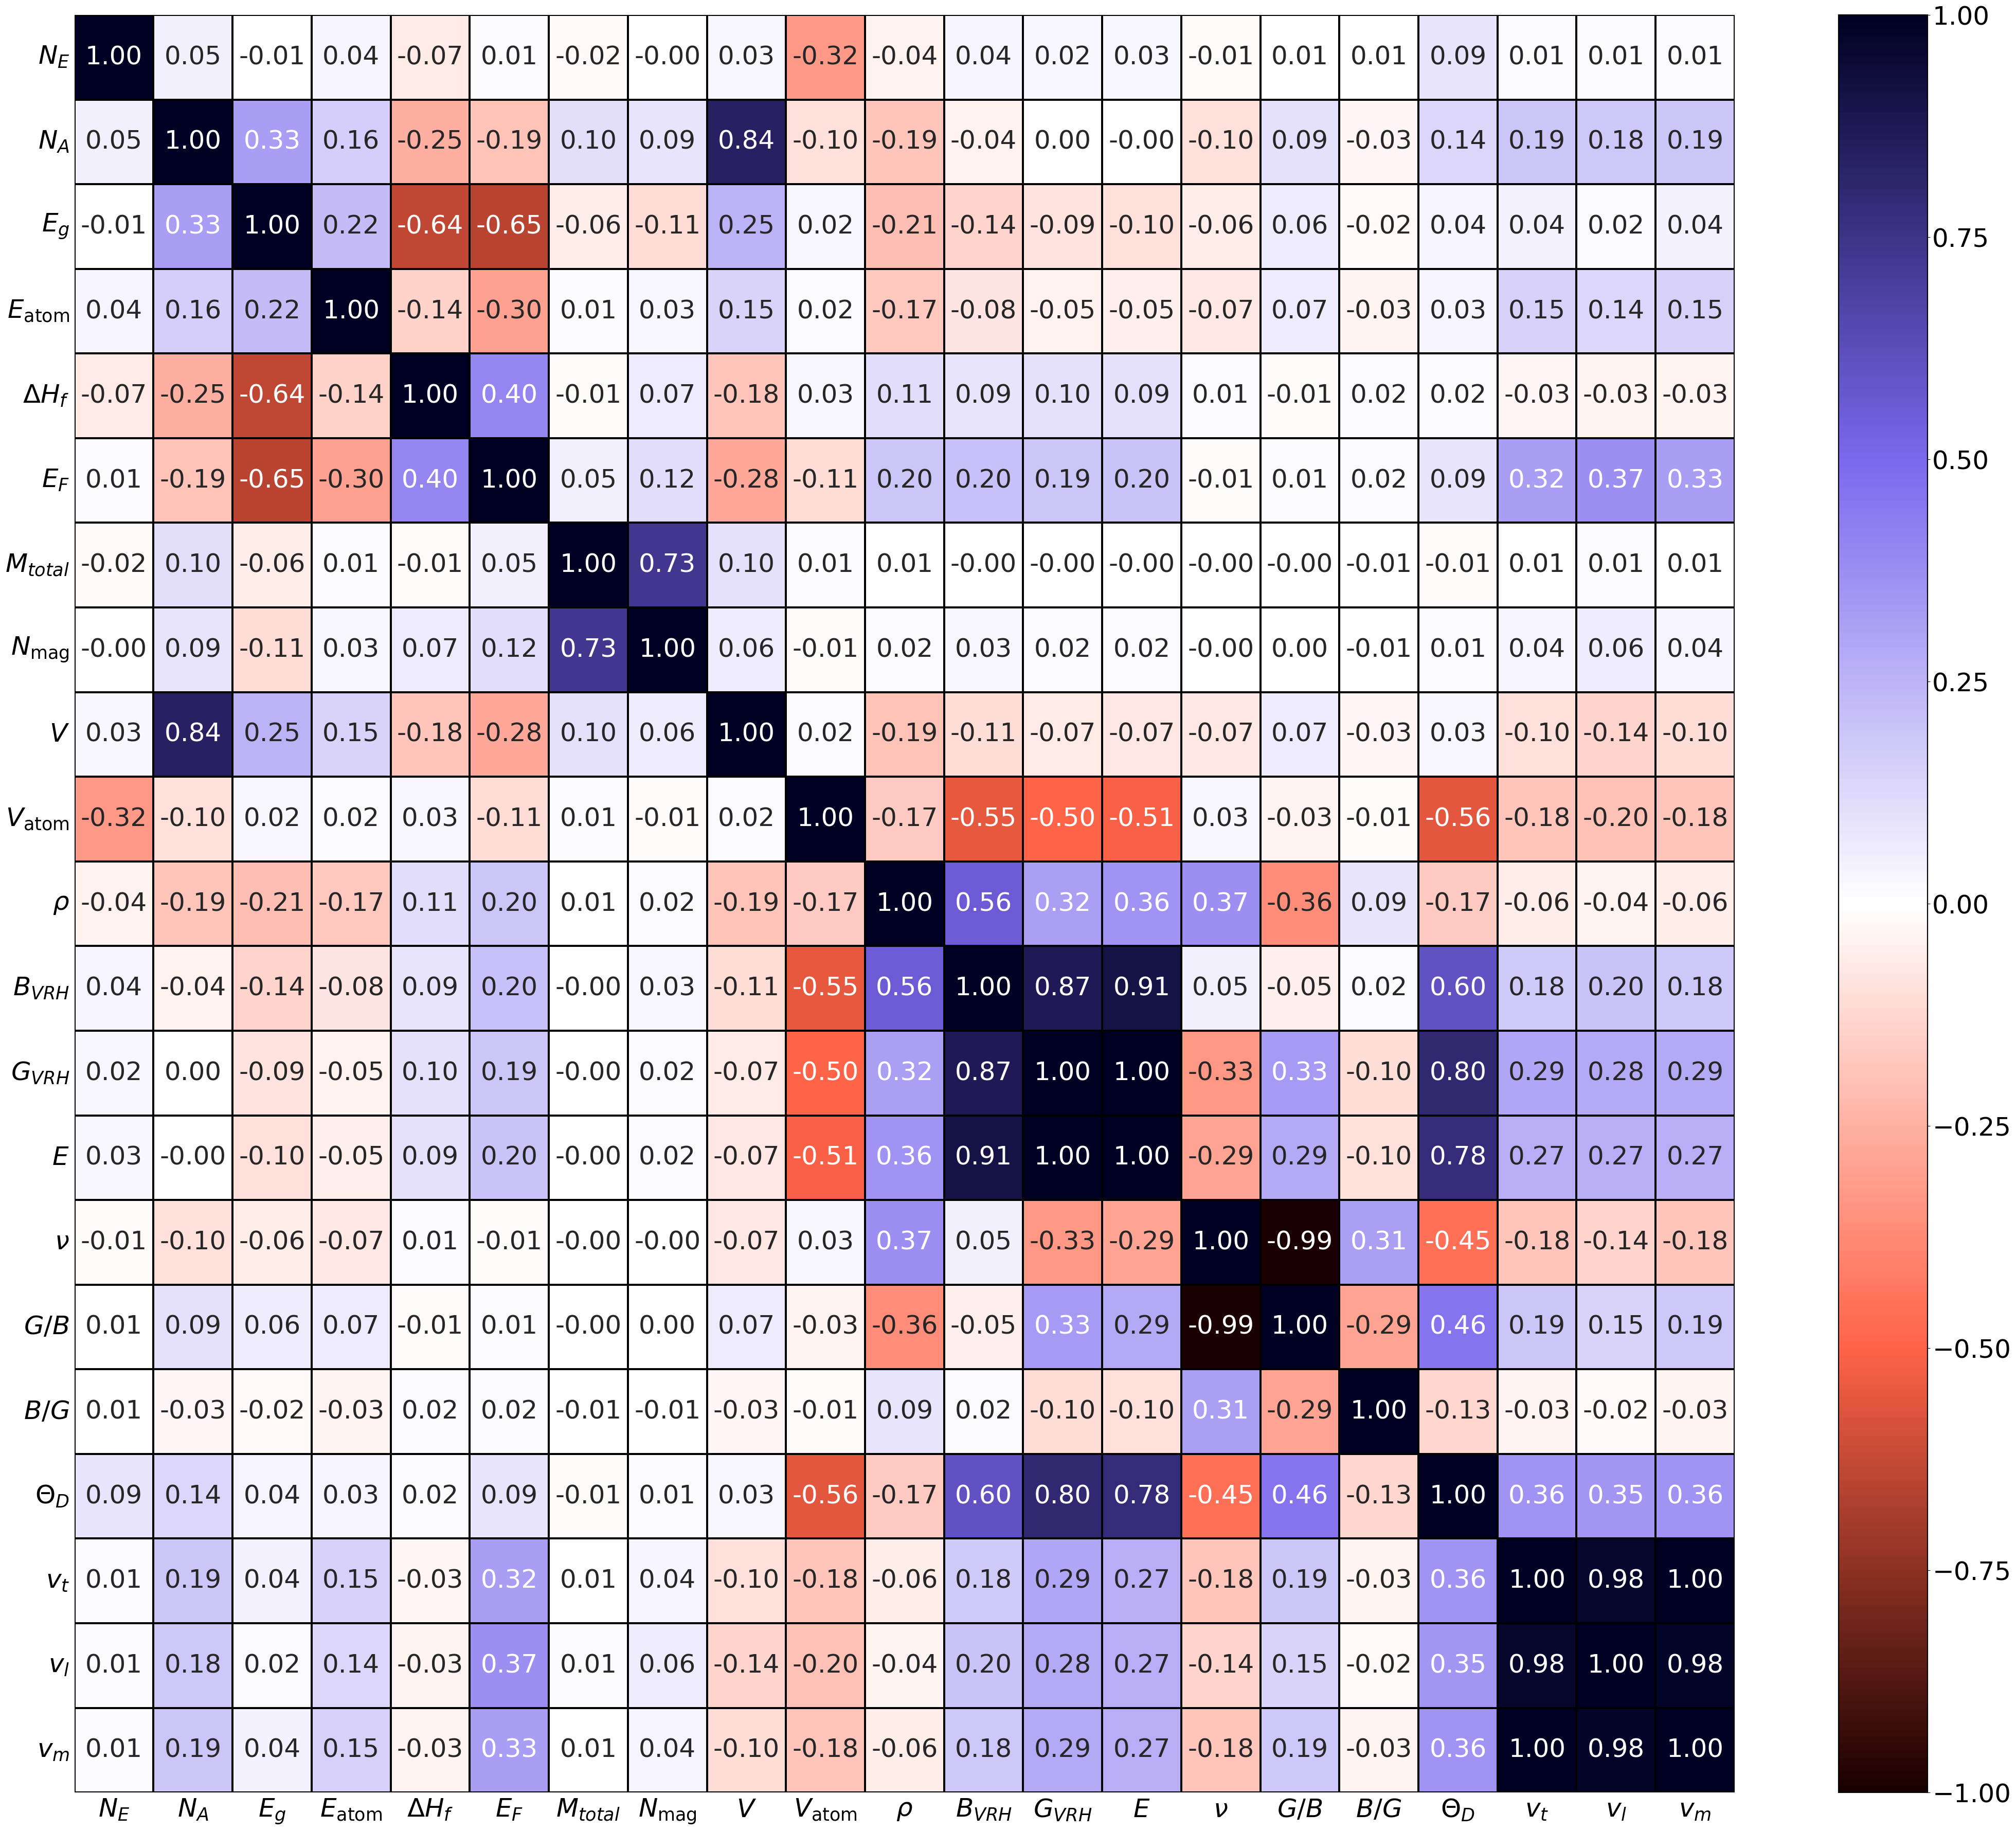


PROCESS COMPLETED SUCCESSFULLY!


In [8]:
##########################################
# Load libraries
##########################################

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
import matplotlib as mpl
import glob

mpl.rcParams['font.family'] = 'sans-serif'

RED_TEXT = "\033[91m"
GREEN_TEXT = "\033[92m"
YELLOW_TEXT = "\033[93m"
RESET_TEXT = "\033[0m"

##########################################
# Helper Functions
##########################################

def get_user_path(prompt_message, default_path=None):
    """Get a valid directory path from user."""
    while True:
        print(f"\n{prompt_message}")
        if default_path:
            print(f"Press Enter to use default: {default_path}")
        
        user_input = input("Enter path: ").strip()
        
        if user_input == "" and default_path:
            return default_path
        
        if user_input == "":
            print(f"{RED_TEXT}Error: Path cannot be empty.{RESET_TEXT}")
            continue
        
        # Expand user home directory if ~ is used
        path = os.path.expanduser(user_input)
        
        if os.path.isdir(path):
            return path
        else:
            print(f"{RED_TEXT}Error: The path '{path}' does not exist.{RESET_TEXT}")
            retry = input("Try again? (yes/no): ").strip().lower()
            if retry != 'yes':
                return None


def list_files_in_directory(directory, extensions):
    """List all files with specified extensions in a directory."""
    files = []
    for ext in extensions:
        pattern = os.path.join(directory, f"*.{ext}")
        files.extend(glob.glob(pattern))
    return [os.path.basename(f) for f in files]


def select_file(directory, extensions):
    """Display files and let user select one."""
    files = list_files_in_directory(directory, extensions)
    
    if not files:
        print(f"{RED_TEXT}No files with extensions {extensions} found in the directory.{RESET_TEXT}")
        return None
    
    print(f"\n{GREEN_TEXT}Available files:{RESET_TEXT}")
    for idx, file in enumerate(files, 1):
        print(f"{idx}. {file}")
    
    while True:
        try:
            choice = input(f"\nSelect file number (1-{len(files)}): ").strip()
            choice_idx = int(choice) - 1
            
            if 0 <= choice_idx < len(files):
                return os.path.join(directory, files[choice_idx])
            else:
                print(f"{RED_TEXT}Invalid selection. Please choose a number between 1 and {len(files)}.{RESET_TEXT}")
        except ValueError:
            print(f"{RED_TEXT}Invalid input. Please enter a number.{RESET_TEXT}")


def load_data_file(file_path):
    """Load data from Excel or CSV file."""
    _, ext = os.path.splitext(file_path)
    ext = ext.lower()
    
    try:
        if ext == '.xlsx' or ext == '.xls':
            return pd.read_excel(file_path)
        elif ext == '.csv':
            return pd.read_csv(file_path)
        else:
            print(f"{RED_TEXT}Unsupported file format: {ext}{RESET_TEXT}")
            return None
    except Exception as e:
        print(f"{RED_TEXT}Error loading file: {e}{RESET_TEXT}")
        return None


def load_symbol_conversion(file_path):
    """Load symbol conversion from text file."""
    symbol_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line and '=' in line:
                    parts = line.split('=', 1)
                    if len(parts) == 2:
                        key = parts[0].strip()
                        value = parts[1].strip()
                        symbol_dict[key] = value
        return symbol_dict
    except Exception as e:
        print(f"{RED_TEXT}Error loading symbol conversion file: {e}{RESET_TEXT}")
        return None


def calculate_dynamic_figure_size(n_params):
    """Calculate figure size based on number of parameters."""
    # Base size for ~5 parameters
    base_size = 10
    scale = max(1.0, n_params / 5.0)
    fig_size = base_size * scale
    return fig_size


##########################################
# Main Program
##########################################

print("="*60)
print("CORRELATION MATRIX GENERATOR")
print("="*60)

# Step 1: Get data file location
print("\n" + "="*60)
print("STEP 1: LOAD DATA FILE")
print("="*60)

home_dir = os.path.expanduser('~')
location_choice = input("\nLoad file from home directory? (yes/no): ").strip().lower()

while location_choice not in ['yes', 'no']:
    print(f"{RED_TEXT}Invalid input. Please enter 'yes' or 'no'.{RESET_TEXT}")
    location_choice = input("Load file from home directory? (yes/no): ").strip().lower()

if location_choice == 'yes':
    data_directory = home_dir
else:
    data_directory = get_user_path("Enter the directory path containing your data file:", home_dir)
    if data_directory is None:
        print(f"{RED_TEXT}Exiting program.{RESET_TEXT}")
        exit()

# Select data file
data_file = select_file(data_directory, ['xlsx', 'xls', 'csv'])
if data_file is None:
    print(f"{RED_TEXT}No file selected. Exiting program.{RESET_TEXT}")
    exit()

print(f"{GREEN_TEXT}Selected file: {os.path.basename(data_file)}{RESET_TEXT}")

# Load data
data = load_data_file(data_file)
if data is None:
    print(f"{RED_TEXT}Failed to load data. Exiting program.{RESET_TEXT}")
    exit()

print(f"{GREEN_TEXT}Data loaded successfully! Shape: {data.shape}{RESET_TEXT}")

# Step 2: Option to drop columns
print("\n" + "="*60)
print("STEP 2: COLUMN SELECTION")
print("="*60)

print(f"\n{YELLOW_TEXT}Columns in the dataset:{RESET_TEXT}")
print(", ".join(data.columns))

drop_choice = input("\nDo you want to drop any columns before calculating correlation? (yes/no): ").strip().lower()

while drop_choice not in ['yes', 'no']:
    print(f"{RED_TEXT}Invalid input. Please enter 'yes' or 'no'.{RESET_TEXT}")
    drop_choice = input("Do you want to drop any columns? (yes/no): ").strip().lower()

if drop_choice == 'yes':
    print(f"\n{YELLOW_TEXT}Current columns in the dataset:{RESET_TEXT}")
    print(", ".join(data.columns))

    while True:
        try:
            num_cols_to_drop = int(input("How many columns do you want to drop? ").strip())
            if num_cols_to_drop <= 0:
                raise ValueError
        except ValueError:
            print(f"{RED_TEXT}Invalid input. Please enter a positive integer.{RESET_TEXT}")
            continue

        print(f"\n{YELLOW_TEXT}Available columns (copy-paste as needed):{RESET_TEXT}")
        print(", ".join(data.columns))

        cols_input = input(f"\nEnter {num_cols_to_drop} column name(s) separated by commas: ").strip()
        cols_to_drop = [col.strip() for col in cols_input.split(",")]

        if len(cols_to_drop) != num_cols_to_drop:
            print(f"{RED_TEXT}Error: You entered {len(cols_to_drop)} columns, expected {num_cols_to_drop}.{RESET_TEXT}")
            continue

        invalid_cols = [col for col in cols_to_drop if col not in data.columns]
        if invalid_cols:
            print(f"{RED_TEXT}Error: Column(s) not found: {', '.join(invalid_cols)}{RESET_TEXT}")
            continue

        data.drop(columns=cols_to_drop, inplace=True)
        print(f"{GREEN_TEXT}Successfully dropped: {', '.join(cols_to_drop)}{RESET_TEXT}")
        break

# Step 3: Symbol mapping for LaTeX labels
print("\n" + "="*60)
print("STEP 3: LABEL CONFIGURATION")
print("="*60)

symbol_choice = input("\nUse column headings as labels or load symbol conversion file? (headings/file): ").strip().lower()

while symbol_choice not in ['headings', 'file']:
    print(f"{RED_TEXT}Invalid input. Please enter 'headings' or 'file'.{RESET_TEXT}")
    symbol_choice = input("Use column headings or load symbol file? (headings/file): ").strip().lower()

symbol_mapping = {}

if symbol_choice == 'file':
    same_path = input("Is symbol_conversion.txt in the same directory as data file? (yes/no): ").strip().lower()
    
    while same_path not in ['yes', 'no']:
        print(f"{RED_TEXT}Invalid input. Please enter 'yes' or 'no'.{RESET_TEXT}")
        same_path = input("Is symbol_conversion.txt in same directory? (yes/no): ").strip().lower()
    
    if same_path == 'yes':
        symbol_dir = data_directory
    else:
        symbol_dir = get_user_path("Enter directory containing symbol_conversion.txt:", data_directory)
        if symbol_dir is None:
            print(f"{YELLOW_TEXT}Using column headings as fallback.{RESET_TEXT}")
            symbol_mapping = {col: col for col in data.columns}
    
    if symbol_dir:
        symbol_file = os.path.join(symbol_dir, 'symbol_conversion.txt')
        if os.path.exists(symbol_file):
            loaded_symbols = load_symbol_conversion(symbol_file)
            if loaded_symbols:
                # Apply loaded symbols, use column name as fallback
                for col in data.columns:
                    symbol_mapping[col] = loaded_symbols.get(col, col)
                print(f"{GREEN_TEXT}Symbol conversion loaded successfully!{RESET_TEXT}")
            else:
                print(f"{YELLOW_TEXT}Failed to load symbols. Using column headings.{RESET_TEXT}")
                symbol_mapping = {col: col for col in data.columns}
        else:
            print(f"{RED_TEXT}symbol_conversion.txt not found. Using column headings.{RESET_TEXT}")
            symbol_mapping = {col: col for col in data.columns}
else:
    # Use column headings
    symbol_mapping = {col: col for col in data.columns}
    print(f"{GREEN_TEXT}Using column headings as labels.{RESET_TEXT}")

# Step 3.1: Font size for labels
font_size = int(input("Enter the font size based on your number of parameters, for figure labels (prefferd 36):"))

# Step 4: Calculate correlation
print("\n" + "="*60)
print("STEP 4: CALCULATING CORRELATION")
print("="*60)

features = data
correlation_matrix = features.corr()

# Keep a copy with original column names for CSV export
correlation_matrix_CSV = correlation_matrix.copy()

# Create display version with symbol mapping
correlation_matrix_display = correlation_matrix.copy()
correlation_matrix_display.rename(index=symbol_mapping, columns=symbol_mapping, inplace=True)

print(f"{GREEN_TEXT}Correlation matrix calculated successfully!{RESET_TEXT}")

# Step 5: Dynamic sizing
n_params = len(correlation_matrix)
fig_size = calculate_dynamic_figure_size(n_params)

print(f"Figure size: {fig_size:.1f} x {fig_size:.1f}")

# Step 6: Create visualization
print("\n" + "="*60)
print("STEP 6: GENERATING VISUALIZATION")
print("="*60)

custom_colors = [
    "#1A0000",
    "tomato",
    "#ffffff",
    "mediumslateblue",
    "#000022",
]

custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors, N=256)

plt.figure(figsize=(fig_size, fig_size * 0.85))

annot_kws = {"size": font_size}

heatmap = sns.heatmap(
    correlation_matrix_display,
    annot=True,
    fmt='.2f',
    cmap=custom_cmap,
    annot_kws=annot_kws,
    vmin=-1,
    vmax=1,
    cbar=True,
    linewidths=1.75,
    linecolor="black"
)

ax = plt.gca()
ax.tick_params(left=False, bottom=False)
ax.set_xticklabels(correlation_matrix_display.columns, fontsize=font_size)
ax.set_yticklabels(correlation_matrix_display.index, fontsize=font_size, rotation=0)

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=font_size)

for spine in colorbar.ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.tight_layout()

print(f"{GREEN_TEXT}Visualization created!{RESET_TEXT}")

# Step 7: Save results
print("\n" + "="*60)
print("STEP 7: SAVE RESULTS")
print("="*60)

save_home = input("\nSave results to home directory? (yes/no): ").strip().lower()

while save_home not in ['yes', 'no']:
    print(f"{RED_TEXT}Invalid input. Please enter 'yes' or 'no'.{RESET_TEXT}")
    save_home = input("Save to home directory? (yes/no): ").strip().lower()

if save_home == 'yes':
    save_directory = home_dir
else:
    save_directory = get_user_path("Enter directory path for saving results:", home_dir)
    if save_directory is None:
        save_directory = home_dir
        print(f"{YELLOW_TEXT}Using home directory as fallback.{RESET_TEXT}")

# Create subdirectory for results
results_dir = os.path.join(save_directory, 'Corr_matrix')
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    print(f"{GREEN_TEXT}Created directory: {results_dir}{RESET_TEXT}")

file_prefix = input("\nEnter prefix for output files: ").strip()
if file_prefix == "":
    file_prefix = "correlation"

# Save figure
fig_path = os.path.join(results_dir, f"{file_prefix}_matrix")

plt.savefig(fig_path + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(fig_path + ".png", dpi=400, bbox_inches='tight')

print(f"{GREEN_TEXT}Figure saved: {fig_path}.pdf and {fig_path}.png{RESET_TEXT}")

# Save CSV with original column names
CSV_path = os.path.join(results_dir, f"{file_prefix}_matrix.csv")
correlation_matrix_CSV.to_csv(CSV_path)
print(f"{GREEN_TEXT}CSV saved (with original column names): {CSV_path}{RESET_TEXT}")

plt.show()

print("\n" + "="*60)
print("PROCESS COMPLETED SUCCESSFULLY!")
print("="*60)